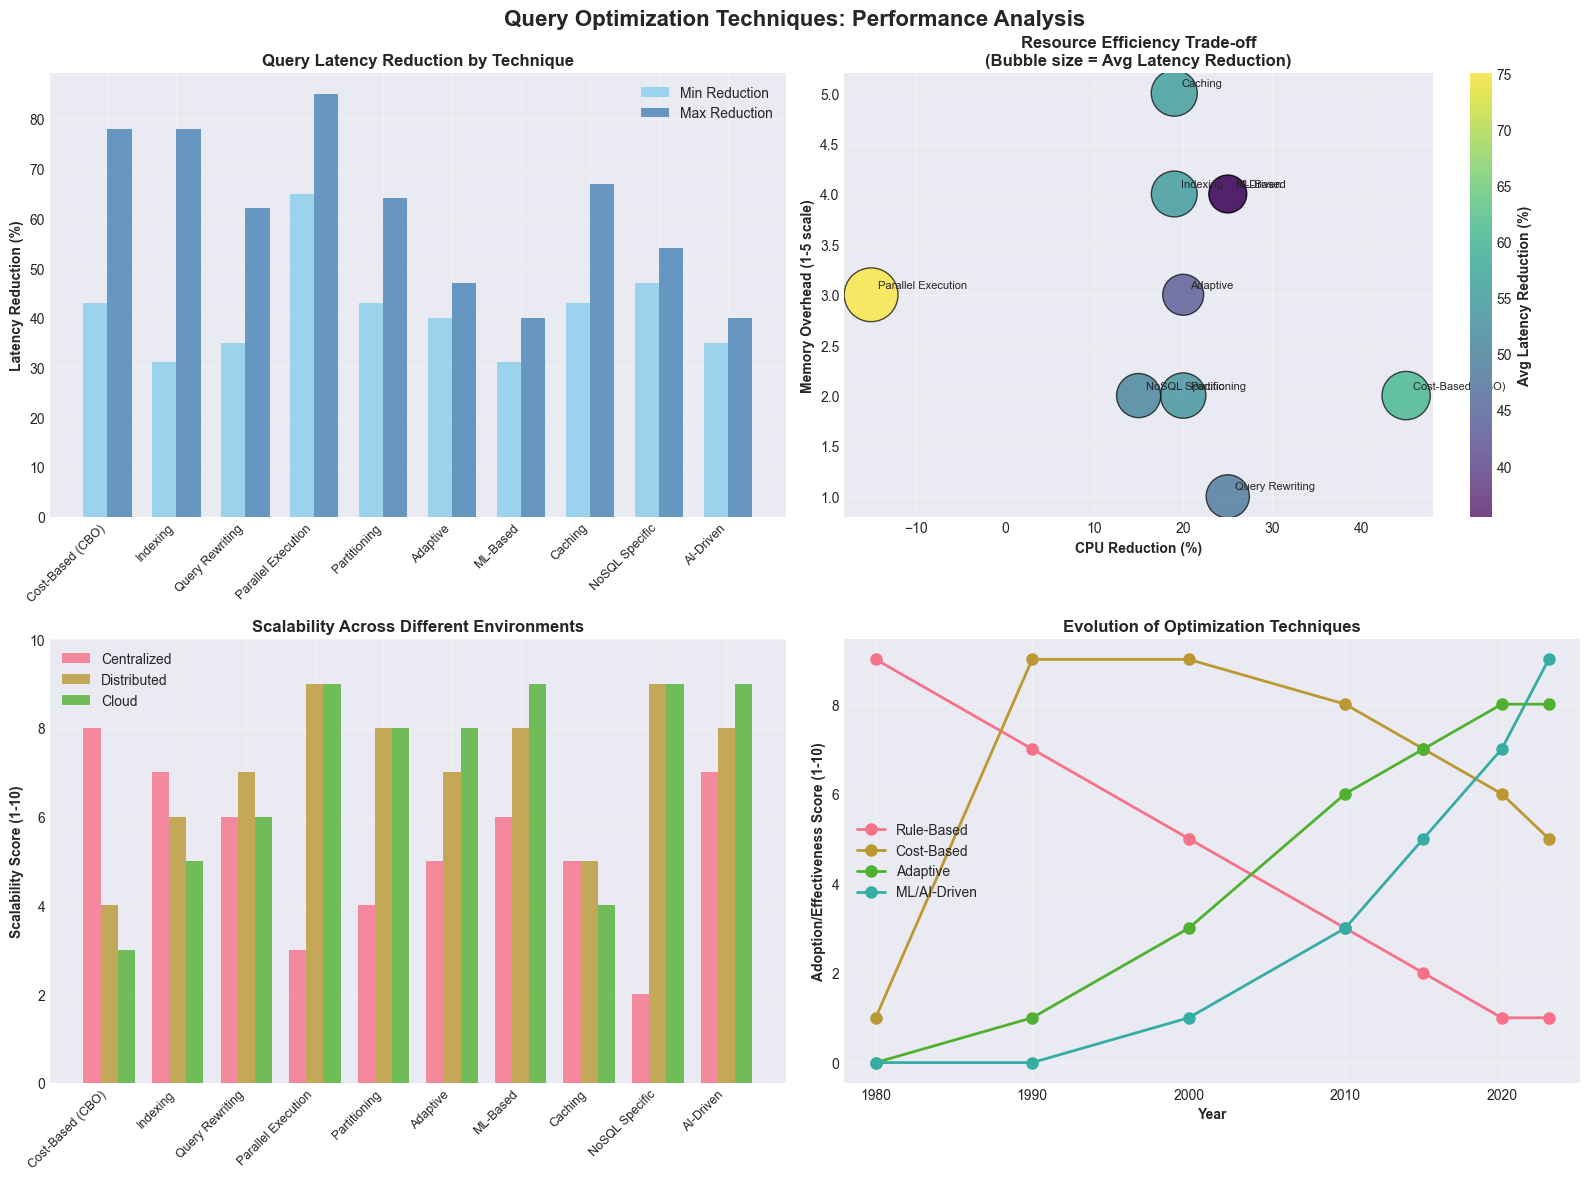

In [1]:
# ===================================================
# FIGURE 1: Performance Comparison Across Techniques
# ===================================================

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Data for performance comparison
techniques = [
    'Cost-Based (CBO)', 'Indexing', 'Query Rewriting', 
    'Parallel Execution', 'Partitioning', 'Adaptive',
    'ML-Based', 'Caching', 'NoSQL Specific', 'AI-Driven'
]

latency_reduction_min = [43, 31, 35, 65, 43, 40, 31, 43, 47, 35]
latency_reduction_max = [78, 78, 62, 85, 64, 47, 40, 67, 54, 40]
avg_reduction = [(min_val + max_val)/2 for min_val, max_val in zip(latency_reduction_min, latency_reduction_max)]
cpu_reduction = [45, 19, 25, -15, 20, 20, 25, 19, 15, 25]  # Negative for parallel (higher CPU but distributed)
memory_overhead = [2, 4, 1, 3, 2, 3, 4, 5, 2, 4]  # Scale 1-5

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Query Optimization Techniques: Performance Analysis', fontsize=16, fontweight='bold')

# 1. Latency Reduction Bar Chart
x_pos = np.arange(len(techniques))
width = 0.35
axes[0,0].bar(x_pos - width/2, latency_reduction_min, width, label='Min Reduction', alpha=0.8, color='skyblue')
axes[0,0].bar(x_pos + width/2, latency_reduction_max, width, label='Max Reduction', alpha=0.8, color='steelblue')
axes[0,0].set_ylabel('Latency Reduction (%)', fontweight='bold')
axes[0,0].set_title('Query Latency Reduction by Technique', fontweight='bold')
axes[0,0].set_xticks(x_pos)
axes[0,0].set_xticklabels(techniques, rotation=45, ha='right', fontsize=9)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. CPU vs Memory Trade-off
scatter = axes[0,1].scatter(cpu_reduction, memory_overhead, s=[a*20 for a in avg_reduction], 
                           c=avg_reduction, cmap='viridis', alpha=0.7, edgecolors='black')
axes[0,1].set_xlabel('CPU Reduction (%)', fontweight='bold')
axes[0,1].set_ylabel('Memory Overhead (1-5 scale)', fontweight='bold')
axes[0,1].set_title('Resource Efficiency Trade-off\n(Bubble size = Avg Latency Reduction)', fontweight='bold')
axes[0,1].grid(True, alpha=0.3)

# Add technique labels to bubbles
for i, tech in enumerate(techniques):
    axes[0,1].annotate(tech, (cpu_reduction[i], memory_overhead[i]), 
                      xytext=(5, 5), textcoords='offset points', fontsize=8)

# Add colorbar
cbar = plt.colorbar(scatter, ax=axes[0,1])
cbar.set_label('Avg Latency Reduction (%)', fontweight='bold')

# 3. Scalability Comparison
scalability_scores = {
    'Centralized': [8, 7, 6, 3, 4, 5, 6, 5, 2, 7],
    'Distributed': [4, 6, 7, 9, 8, 7, 8, 5, 9, 8],
    'Cloud': [3, 5, 6, 9, 8, 8, 9, 4, 9, 9]
}

x = np.arange(len(techniques))
width = 0.25
multiplier = 0

for env, scores in scalability_scores.items():
    offset = width * multiplier
    rects = axes[1,0].bar(x + offset, scores, width, label=env, alpha=0.8)
    multiplier += 1

axes[1,0].set_ylabel('Scalability Score (1-10)', fontweight='bold')
axes[1,0].set_title('Scalability Across Different Environments', fontweight='bold')
axes[1,0].set_xticks(x + width)
axes[1,0].set_xticklabels(techniques, rotation=45, ha='right', fontsize=9)
axes[1,0].legend()
axes[1,0].set_ylim(0, 10)
axes[1,0].grid(True, alpha=0.3)

# 4. Technique Evolution Timeline
years = [1980, 1990, 2000, 2010, 2015, 2020, 2023]
tech_evolution = {
    'Rule-Based': [9, 7, 5, 3, 2, 1, 1],
    'Cost-Based': [1, 9, 9, 8, 7, 6, 5],
    'Adaptive': [0, 1, 3, 6, 7, 8, 8],
    'ML/AI-Driven': [0, 0, 1, 3, 5, 7, 9]
}

for tech, scores in tech_evolution.items():
    axes[1,1].plot(years, scores, marker='o', linewidth=2, markersize=8, label=tech)

axes[1,1].set_xlabel('Year', fontweight='bold')
axes[1,1].set_ylabel('Adoption/Effectiveness Score (1-10)', fontweight='bold')
axes[1,1].set_title('Evolution of Optimization Techniques', fontweight='bold')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)
axes[1,1].set_xlim(1978, 2025)

plt.tight_layout()
plt.savefig('../results/fig1_new_optimization_technique.png')
plt.show()

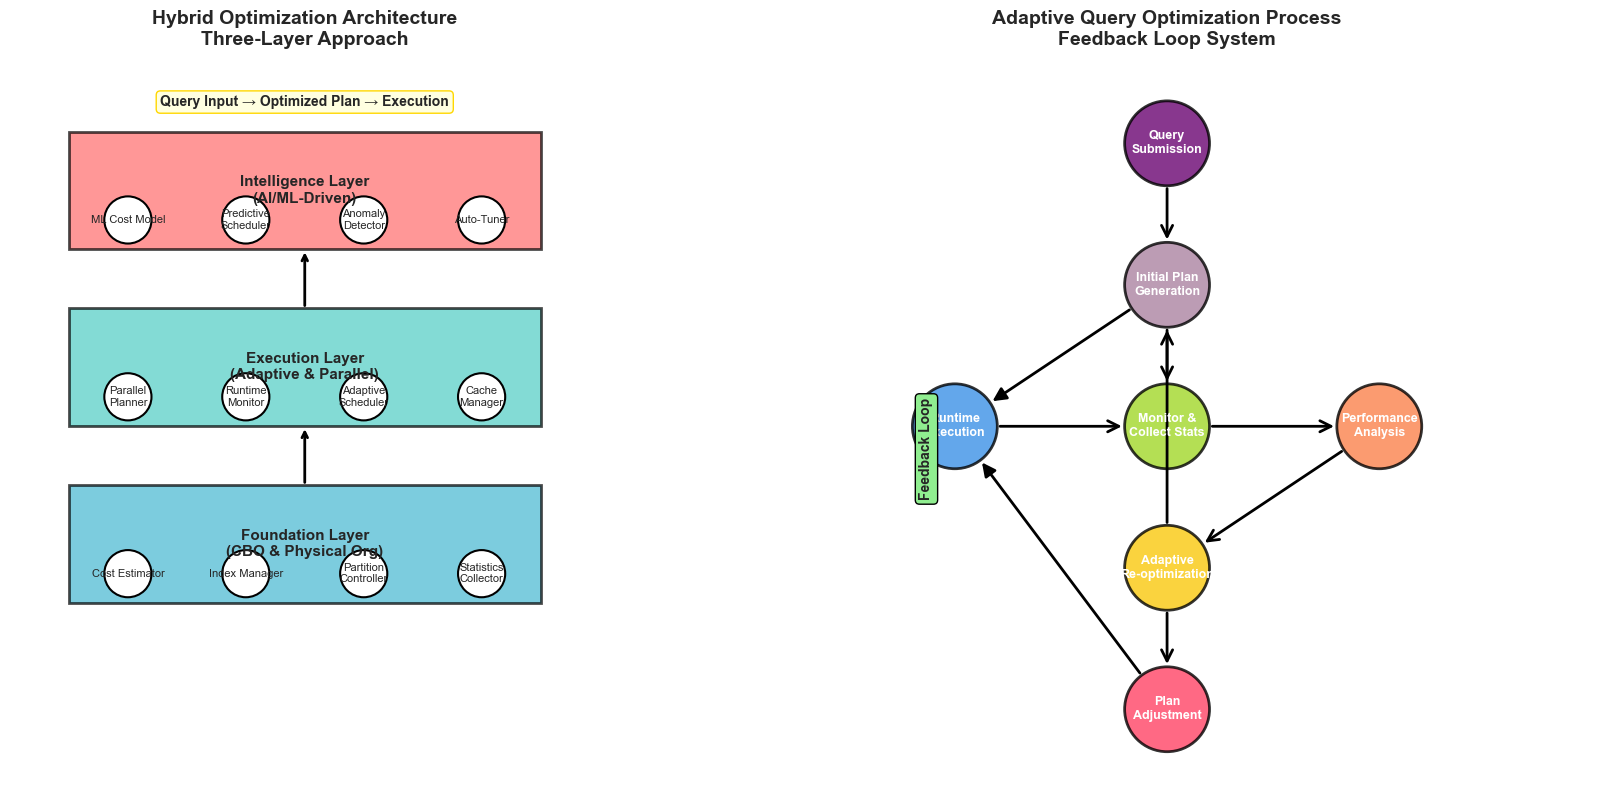

In [12]:
# ===================================================
# FIGURE 2: Performance Comparison Across Techniques
# ===================================================

from matplotlib.patches import FancyArrowPatch, Rectangle, Circle 

# Create architecture diagram
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# 1. Layered Architecture Diagram
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 12)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('Hybrid Optimization Architecture\nThree-Layer Approach', 
              fontweight='bold', fontsize=14, pad=20)

# Define layers
layers = [
    {"name": "Intelligence Layer\n(AI/ML-Driven)", "y": 9, "color": "#FF6B6B", "height": 2},
    {"name": "Execution Layer\n(Adaptive & Parallel)", "y": 6, "color": "#4ECDC4", "height": 2},
    {"name": "Foundation Layer\n(CBO & Physical Org)", "y": 3, "color": "#45B7D1", "height": 2}
]

# Draw layers
for i, layer in enumerate(layers):
    rect = Rectangle((1, layer["y"]), 8, layer["height"], 
                     facecolor=layer["color"], alpha=0.7, 
                     edgecolor='black', linewidth=2)
    ax1.add_patch(rect)
    ax1.text(5, layer["y"] + layer["height"]/2, layer["name"], 
             ha='center', va='center', fontweight='bold', fontsize=11)

# Add components to each layer
components = {
    "Foundation": ["Cost Estimator", "Index Manager", "Partition\nController", "Statistics\nCollector"],
    "Execution": ["Parallel\nPlanner", "Runtime\nMonitor", "Adaptive\nScheduler", "Cache\nManager"],
    "Intelligence": ["ML Cost Model", "Predictive\nScheduler", "Anomaly\nDetector", "Auto-Tuner"]
}

y_positions = [3.5, 6.5, 9.5]
for idx, (layer_name, comps) in enumerate(components.items()):
    y = y_positions[idx]
    for j, comp in enumerate(comps):
        x = 2 + j * 2
        circle = Circle((x, y), 0.4, facecolor='white', edgecolor='black', linewidth=1.5)
        ax1.add_patch(circle)
        ax1.text(x, y, comp, ha='center', va='center', fontsize=8)

# Add arrows between layers
for i in range(len(layers)-1):
    ax1.annotate('', xy=(5, layers[i]["y"]), xytext=(5, layers[i+1]["y"] + layers[i+1]["height"]),
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))

ax1.text(5, 11.5, "Query Input → Optimized Plan → Execution", 
         ha='center', va='center', fontweight='bold', fontsize=10, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gold"))

# 2. Adaptive Optimization Flowchart
ax2.set_xlim(0, 12)
ax2.set_ylim(0, 10)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('Adaptive Query Optimization Process\nFeedback Loop System', 
              fontweight='bold', fontsize=14, pad=20)

# Define nodes for flowchart
nodes = [
    {"id": 1, "label": "Query\nSubmission", "pos": (6, 9), "color": "#6A0572"},
    {"id": 2, "label": "Initial Plan\nGeneration", "pos": (6, 7), "color": "#AB83A1"},
    {"id": 3, "label": "Runtime\nExecution", "pos": (3, 5), "color": "#3C91E6"},
    {"id": 4, "label": "Monitor &\nCollect Stats", "pos": (6, 5), "color": "#A2D729"},
    {"id": 5, "label": "Performance\nAnalysis", "pos": (9, 5), "color": "#FA824C"},
    {"id": 6, "label": "Adaptive\nRe-optimization", "pos": (6, 3), "color": "#F9C80E"},
    {"id": 7, "label": "Plan\nAdjustment", "pos": (6, 1), "color": "#FF4365"}
]

# Draw nodes
for node in nodes:
    circle = Circle(node["pos"], 0.6, facecolor=node["color"], alpha=0.8, 
                    edgecolor='black', linewidth=2)
    ax2.add_patch(circle)
    ax2.text(node["pos"][0], node["pos"][1], node["label"], 
             ha='center', va='center', fontsize=9, fontweight='bold', color='white')

# Draw connections
connections = [
    (1, 2), (2, 3), (2, 4), (3, 4), (4, 5), (5, 6), (6, 7),
    (7, 3),  # Feedback loop
    (6, 2)   # Re-optimization path
]

for src, dst in connections:
    src_pos = nodes[src-1]["pos"]
    dst_pos = nodes[dst-1]["pos"]
    
    # Adjust arrow start/end to avoid overlapping with circles
    dx = dst_pos[0] - src_pos[0]
    dy = dst_pos[1] - src_pos[1]
    dist = np.sqrt(dx*dx + dy*dy)
    
    start_x = src_pos[0] + (dx/dist)*0.6
    start_y = src_pos[1] + (dy/dist)*0.6
    end_x = dst_pos[0] - (dx/dist)*0.6
    end_y = dst_pos[1] - (dy/dist)*0.6
    
    arrow_style = '->' if dst != 3 else '-|>'
    arrow = FancyArrowPatch((start_x, start_y), (end_x, end_y),
                            arrowstyle=arrow_style, linewidth=2, 
                            color='black', mutation_scale=20)
    ax2.add_patch(arrow)

# Add feedback loop label
ax2.text(2.5, 4, "Feedback Loop", rotation=90, fontweight='bold', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen"))

plt.tight_layout()
plt.savefig('../results/fig2_new_architecture_process_flow.png')
plt.show()

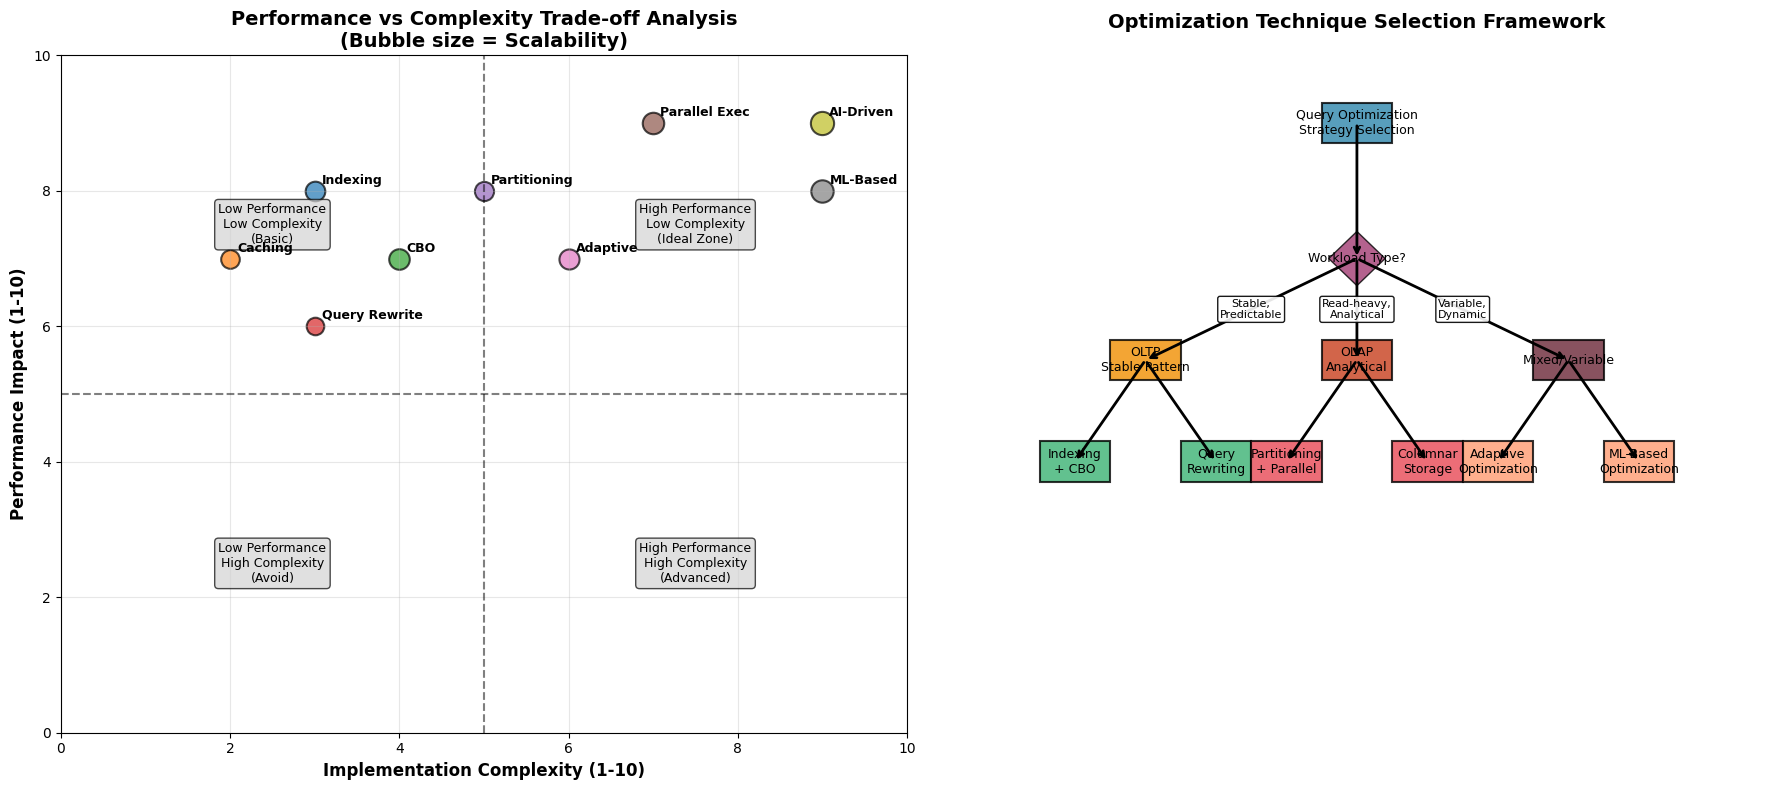

In [5]:
# =================================================
# FIGURE 3: Trade-off Analysis & Decision Framework
# =================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Create quadrant chart and decision tree
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# 1. Quadrant Chart (Performance vs Complexity)
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axhline(y=5, color='black', linestyle='--', alpha=0.5)
ax1.axvline(x=5, color='black', linestyle='--', alpha=0.5)

# Define quadrants
quadrant_labels = [
    ("High Performance\nLow Complexity\n(Ideal Zone)", 7.5, 7.5),
    ("High Performance\nHigh Complexity\n(Advanced)", 7.5, 2.5),
    ("Low Performance\nLow Complexity\n(Basic)", 2.5, 7.5),
    ("Low Performance\nHigh Complexity\n(Avoid)", 2.5, 2.5)
]

for label, x, y in quadrant_labels:
    ax1.text(x, y, label, ha='center', va='center', fontsize=9, 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.7))

# Plot techniques in quadrants
tech_data = {
    'Indexing': {'perf': 8, 'complex': 3, 'size': 200},
    'Caching': {'perf': 7, 'complex': 2, 'size': 180},
    'CBO': {'perf': 7, 'complex': 4, 'size': 220},
    'Query Rewrite': {'perf': 6, 'complex': 3, 'size': 160},
    'Partitioning': {'perf': 8, 'complex': 5, 'size': 190},
    'Parallel Exec': {'perf': 9, 'complex': 7, 'size': 240},
    'Adaptive': {'perf': 7, 'complex': 6, 'size': 210},
    'ML-Based': {'perf': 8, 'complex': 9, 'size': 260},
    'AI-Driven': {'perf': 9, 'complex': 9, 'size': 280}
}

for tech, data in tech_data.items():
    scatter = ax1.scatter(data['complex'], data['perf'], s=data['size'], 
                         alpha=0.7, edgecolors='black', linewidth=1.5)
    ax1.annotate(tech, (data['complex'], data['perf']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

ax1.set_xlabel('Implementation Complexity (1-10)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Performance Impact (1-10)', fontweight='bold', fontsize=12)
ax1.set_title('Performance vs Complexity Trade-off Analysis\n(Bubble size = Scalability)', 
              fontweight='bold', fontsize=14)
ax1.grid(True, alpha=0.3)

# 2. Decision Tree for Technique Selection
ax2.set_xlim(0, 12)
ax2.set_ylim(0, 10)
ax2.axis('off')
ax2.set_title('Optimization Technique Selection Framework', 
              fontweight='bold', fontsize=14, pad=20)

# Draw decision tree
decision_nodes = [
    {"id": "start", "label": "Query Optimization\nStrategy Selection", "pos": (6, 9), "color": "#2E86AB"},
    {"id": "q1", "label": "Workload Type?", "pos": (6, 7), "color": "#A23B72"},
    {"id": "oltp", "label": "OLTP\nStable Pattern", "pos": (3, 5.5), "color": "#F18F01"},
    {"id": "olap", "label": "OLAP\nAnalytical", "pos": (6, 5.5), "color": "#C73E1D"},
    {"id": "mixed", "label": "Mixed/Variable", "pos": (9, 5.5), "color": "#6B2737"},
    
    # OLTP decisions
    {"id": "oltp1", "label": "Indexing\n+ CBO", "pos": (2, 4), "color": "#3BB273"},
    {"id": "oltp2", "label": "Query\nRewriting", "pos": (4, 4), "color": "#3BB273"},
    
    # OLAP decisions
    {"id": "olap1", "label": "Partitioning\n+ Parallel", "pos": (5, 4), "color": "#E84855"},
    {"id": "olap2", "label": "Columnar\nStorage", "pos": (7, 4), "color": "#E84855"},
    
    # Mixed decisions
    {"id": "mixed1", "label": "Adaptive\nOptimization", "pos": (8, 4), "color": "#FF9B71"},
    {"id": "mixed2", "label": "ML-Based\nOptimization", "pos": (10, 4), "color": "#FF9B71"},
]

# Draw nodes
for node in decision_nodes:
    if "?" in node["label"]:
        # Diamond shape for decision nodes
        diamond = plt.Polygon([
            (node["pos"][0], node["pos"][1] + 0.4),
            (node["pos"][0] + 0.4, node["pos"][1]),
            (node["pos"][0], node["pos"][1] - 0.4),
            (node["pos"][0] - 0.4, node["pos"][1])
        ], facecolor=node["color"], alpha=0.8, edgecolor='black')
        ax2.add_patch(diamond)
    else:
        # Rectangle for action nodes
        rect = Rectangle((node["pos"][0]-0.5, node["pos"][1]-0.3), 1, 0.6,
                        facecolor=node["color"], alpha=0.8, edgecolor='black', linewidth=1.5)
        ax2.add_patch(rect)
    
    ax2.text(node["pos"][0], node["pos"][1], node["label"], 
             ha='center', va='center', fontsize=9, color='black')

# Draw connections
connections = [
    ("start", "q1"),
    ("q1", "oltp"), ("q1", "olap"), ("q1", "mixed"),
    ("oltp", "oltp1"), ("oltp", "oltp2"),
    ("olap", "olap1"), ("olap", "olap2"),
    ("mixed", "mixed1"), ("mixed", "mixed2")
]

# Add connection labels
connection_labels = {
    ("q1", "oltp"): "Stable,\nPredictable",
    ("q1", "olap"): "Read-heavy,\nAnalytical",
    ("q1", "mixed"): "Variable,\nDynamic"
}

for src_id, dst_id in connections:
    src = next(n for n in decision_nodes if n["id"] == src_id)
    dst = next(n for n in decision_nodes if n["id"] == dst_id)
    
    # Draw arrow
    ax2.annotate('', xy=dst["pos"], xytext=src["pos"],
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))
    
    # Add label for main branches
    if (src_id, dst_id) in connection_labels:
        mid_x = (src["pos"][0] + dst["pos"][0]) / 2
        mid_y = (src["pos"][1] + dst["pos"][1]) / 2
        ax2.text(mid_x, mid_y, connection_labels[(src_id, dst_id)], 
                ha='center', va='center', fontsize=8, 
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.9))

plt.tight_layout()
plt.savefig('../results/fig3_new_tradeoff_analysis.png')
plt.show()

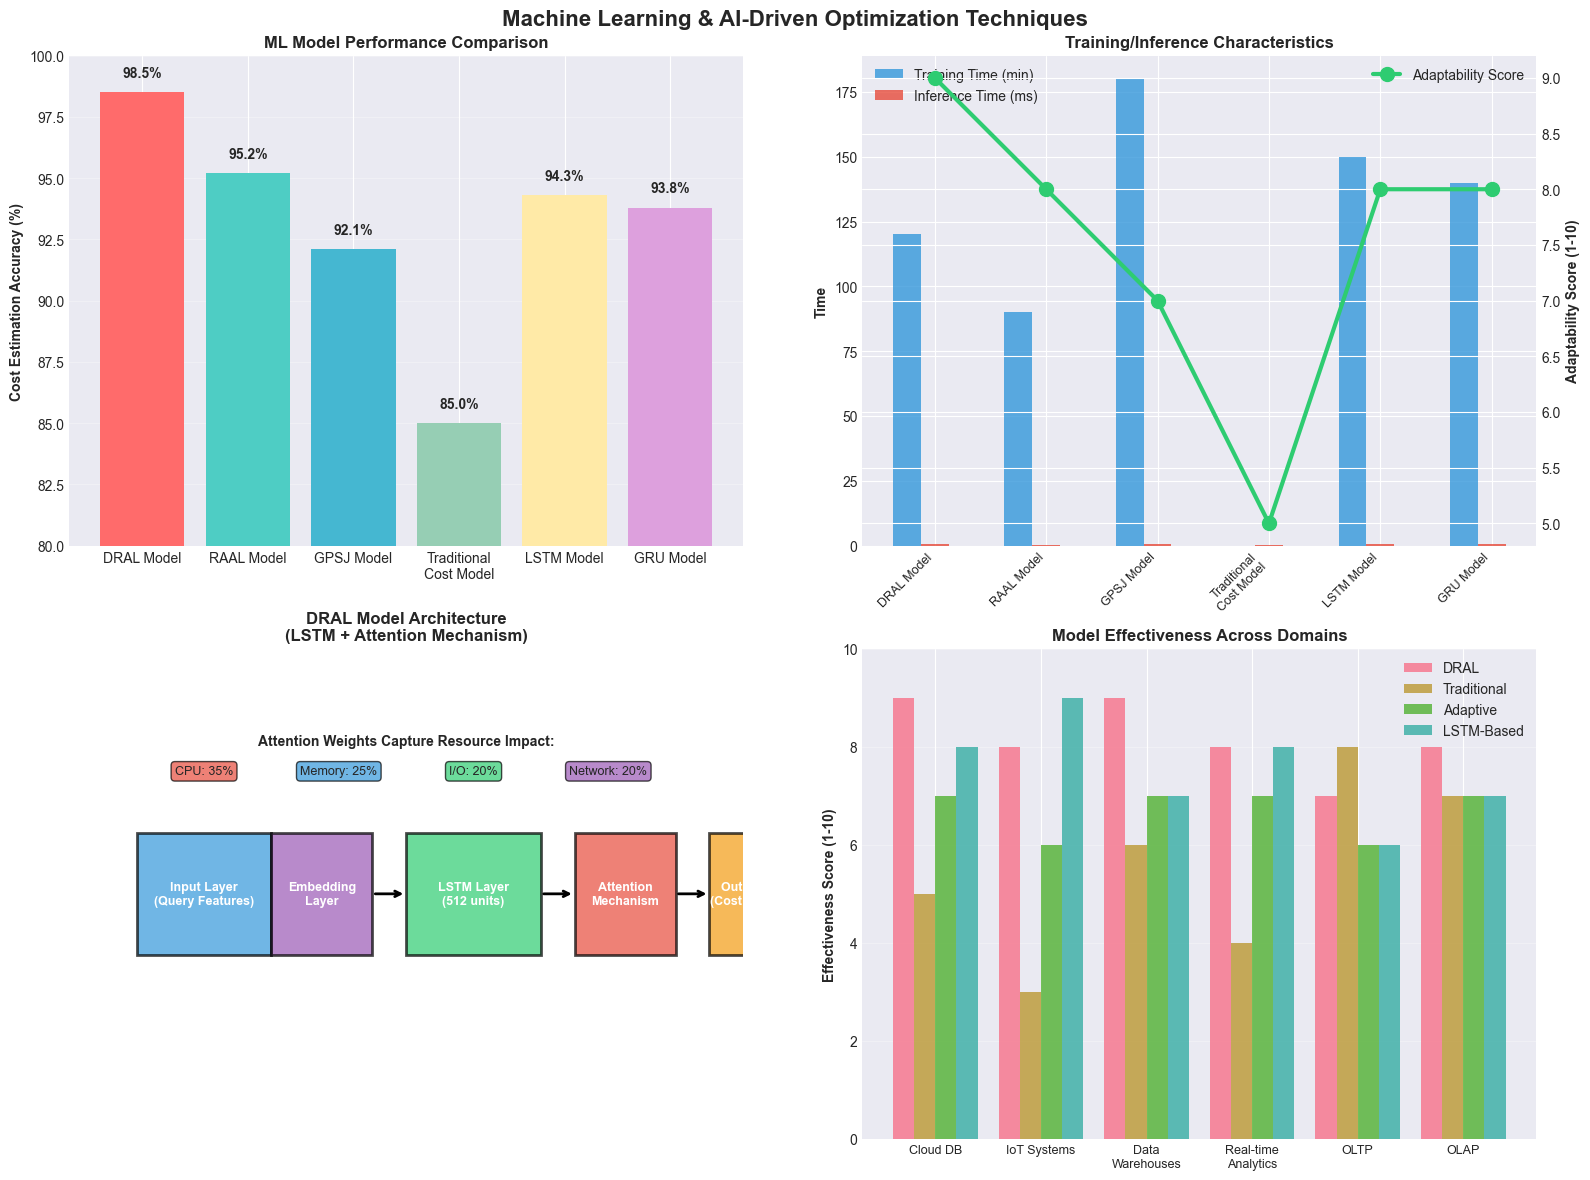

In [9]:
# ====================================
# FIGURE 4: ML/AI Technique Comparison
# ====================================

from matplotlib.patches import Rectangle

# Create ML/AI techniques comparison
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Machine Learning & AI-Driven Optimization Techniques', fontsize=16, fontweight='bold')

# 1. Accuracy Comparison
ml_models = ['DRAL Model', 'RAAL Model', 'GPSJ Model', 'Traditional\nCost Model', 'LSTM Model', 'GRU Model']
accuracy = [98.5, 95.2, 92.1, 85.0, 94.3, 93.8]
latency_reduction = [40, 35, 32, 25, 36, 35]

bars1 = ax1.bar(ml_models, accuracy, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD'])
ax1.set_ylabel('Cost Estimation Accuracy (%)', fontweight='bold')
ax1.set_title('ML Model Performance Comparison', fontweight='bold')
ax1.set_ylim(80, 100)
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars1, accuracy):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{acc}%', ha='center', va='bottom', fontweight='bold')

# 2. Training vs Inference Characteristics
training_time = [120, 90, 180, 0, 150, 140]  # minutes
inference_time = [0.5, 0.4, 0.6, 0.1, 0.8, 0.7]  # milliseconds
adaptability = [9, 8, 7, 5, 8, 8]  # score 1-10

x = np.arange(len(ml_models))
width = 0.25

bars2a = ax2.bar(x - width, training_time, width, label='Training Time (min)', alpha=0.8, color='#3498DB')
bars2b = ax2.bar(x, inference_time, width, label='Inference Time (ms)', alpha=0.8, color='#E74C3C')
ax2_twin = ax2.twinx()
line2 = ax2_twin.plot(x, adaptability, 'o-', color='#2ECC71', linewidth=3, 
                      markersize=10, label='Adaptability Score')

ax2.set_xticks(x)
ax2.set_xticklabels(ml_models, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Time', fontweight='bold')
ax2_twin.set_ylabel('Adaptability Score (1-10)', fontweight='bold')
ax2.set_title('Training/Inference Characteristics', fontweight='bold')
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

# 3. DRAL Model Architecture Diagram
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 8)
ax3.axis('off')
ax3.set_title('DRAL Model Architecture\n(LSTM + Attention Mechanism)', fontweight='bold', fontsize=12)

# Draw layers
layers_dral = [
    {"name": "Input Layer\n(Query Features)", "x": 1, "width": 2, "color": "#3498DB"},
    {"name": "Embedding\nLayer", "x": 3, "width": 1.5, "color": "#9B59B6"},
    {"name": "LSTM Layer\n(512 units)", "x": 5, "width": 2, "color": "#2ECC71"},
    {"name": "Attention\nMechanism", "x": 7.5, "width": 1.5, "color": "#E74C3C"},
    {"name": "Output Layer\n(Cost Prediction)", "x": 9.5, "width": 1.5, "color": "#F39C12"}
]

for layer in layers_dral:
    rect = Rectangle((layer["x"], 3), layer["width"], 2, 
                     facecolor=layer["color"], alpha=0.7, 
                     edgecolor='black', linewidth=2)
    ax3.add_patch(rect)
    ax3.text(layer["x"] + layer["width"]/2, 4, layer["name"], 
             ha='center', va='center', fontweight='bold', fontsize=9, color='white')

# Connect layers
for i in range(len(layers_dral)-1):
    x1 = layers_dral[i]["x"] + layers_dral[i]["width"]
    x2 = layers_dral[i+1]["x"]
    ax3.annotate('', xy=(x2, 4), xytext=(x1, 4),
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# Add resource impact visualization
ax3.text(5, 6.5, "Attention Weights Capture Resource Impact:", 
         ha='center', va='center', fontweight='bold', fontsize=10)

resources = ['CPU', 'Memory', 'I/O', 'Network']
weights = [0.35, 0.25, 0.20, 0.20]
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

for i, (res, wt, col) in enumerate(zip(resources, weights, colors)):
    ax3.text(2 + i*2, 6, f"{res}: {wt*100:.0f}%", 
             ha='center', va='center', fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", facecolor=col, alpha=0.7))

# 4. Application Domain Effectiveness
domains = ['Cloud DB', 'IoT Systems', 'Data\nWarehouses', 'Real-time\nAnalytics', 'OLTP', 'OLAP']
effectiveness = {
    'DRAL': [9, 8, 9, 8, 7, 8],
    'Traditional': [5, 3, 6, 4, 8, 7],
    'Adaptive': [7, 6, 7, 7, 6, 7],
    'LSTM-Based': [8, 9, 7, 8, 6, 7]
}

x_domain = np.arange(len(domains))
width_domain = 0.2
multiplier = 0

for model, scores in effectiveness.items():
    offset = width_domain * multiplier
    bars4 = ax4.bar(x_domain + offset, scores, width_domain, label=model, alpha=0.8)
    multiplier += 1

ax4.set_xticks(x_domain + width_domain * 1.5)
ax4.set_xticklabels(domains, fontsize=9)
ax4.set_ylabel('Effectiveness Score (1-10)', fontweight='bold')
ax4.set_title('Model Effectiveness Across Domains', fontweight='bold')
ax4.legend()
ax4.set_ylim(0, 10)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../results/fig4_new_ml_ai.png')
plt.show()

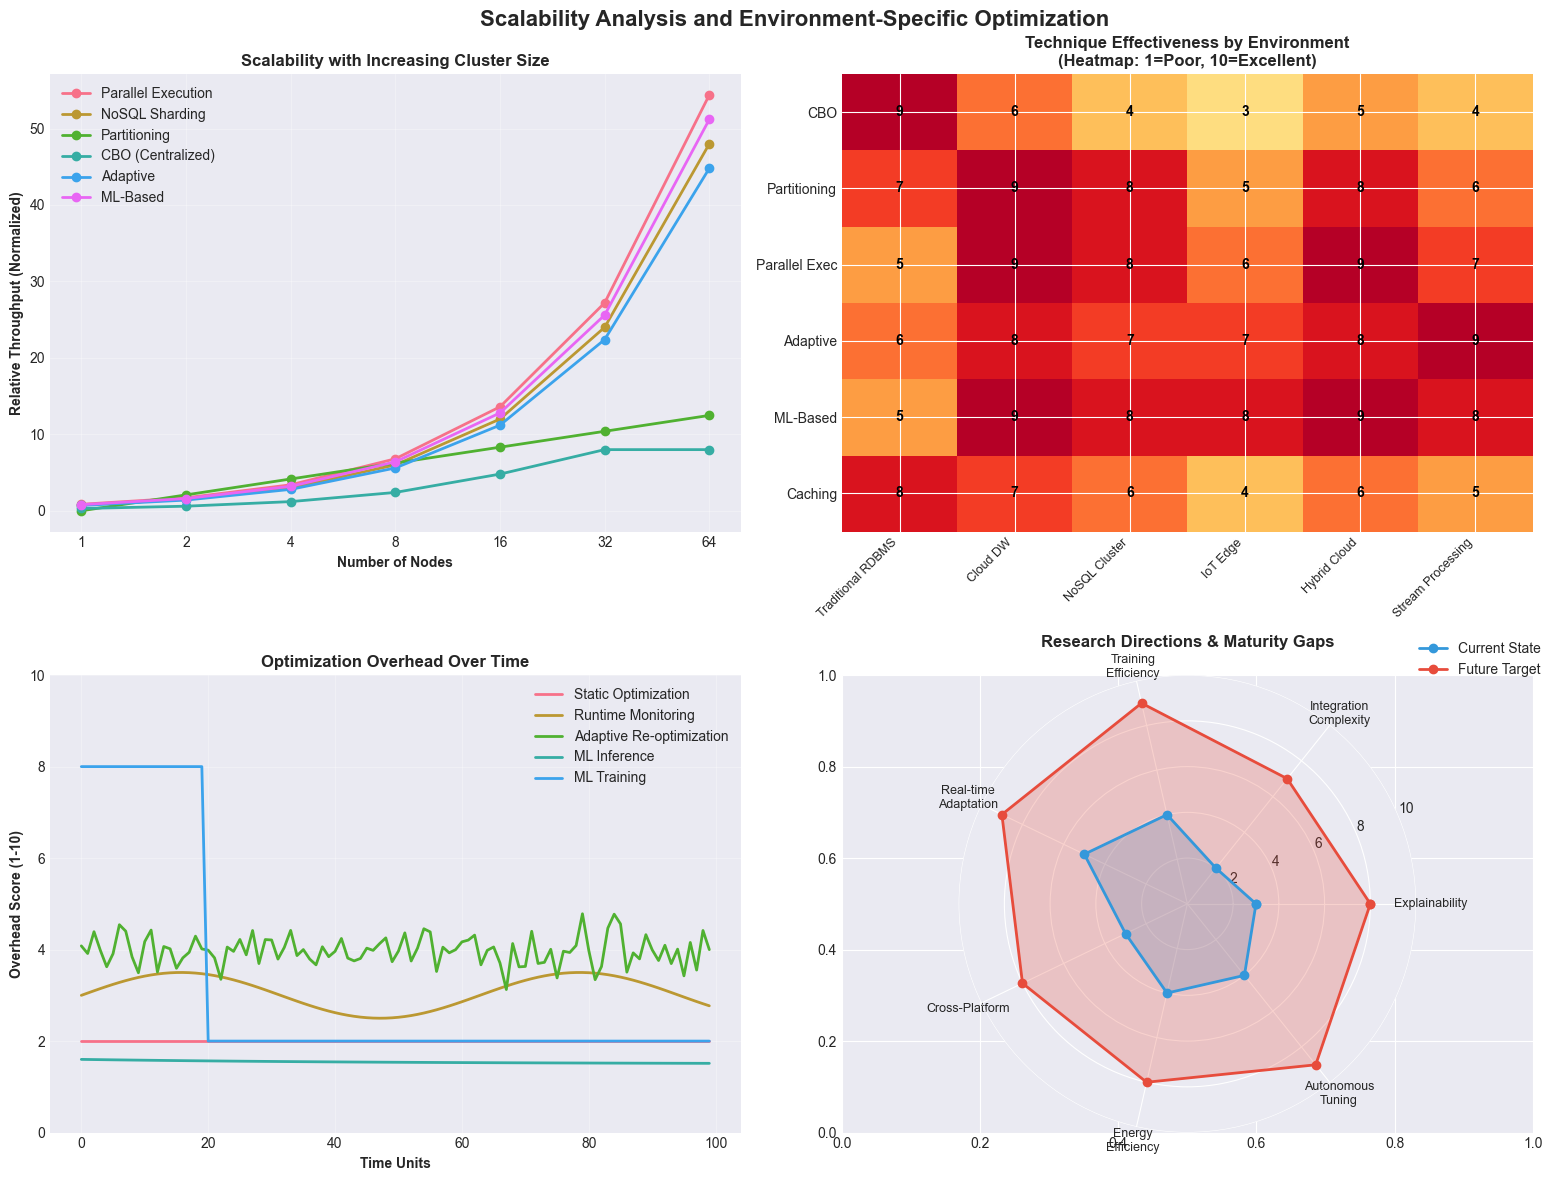

In [4]:
# ==============================================
# FIGURE 5: Scalability and Environment Analysis
# ==============================================

# Create scalability and environment analysis
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Scalability Analysis and Environment-Specific Optimization', fontsize=16, fontweight='bold')

# 1. Scalability Trends with Node Count
node_counts = np.array([1, 2, 4, 8, 16, 32, 64])

# Define throughput functions for different techniques
throughput_data = {
    'Parallel Execution': node_counts * 0.85,  # Near-linear scaling
    'NoSQL Sharding': node_counts * 0.75,      # Good scaling
    'Partitioning': np.log(node_counts) * 3,   # Logarithmic scaling
    'CBO (Centralized)': np.minimum(8, node_counts * 0.3),  # Limited scaling
    'Adaptive': node_counts * 0.7,             # Good scaling
    'ML-Based': node_counts * 0.8              # Excellent scaling
}

for tech, throughput in throughput_data.items():
    ax1.plot(node_counts, throughput, marker='o', linewidth=2, markersize=6, label=tech)

ax1.set_xlabel('Number of Nodes', fontweight='bold')
ax1.set_ylabel('Relative Throughput (Normalized)', fontweight='bold')
ax1.set_title('Scalability with Increasing Cluster Size', fontweight='bold')
ax1.set_xscale('log', base=2)
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_xticks(node_counts)
ax1.set_xticklabels(node_counts)

# 2. Environment-Specific Heatmap
environments = ['Traditional RDBMS', 'Cloud DW', 'NoSQL Cluster', 'IoT Edge', 'Hybrid Cloud', 'Stream Processing']
techniques_env = ['CBO', 'Partitioning', 'Parallel Exec', 'Adaptive', 'ML-Based', 'Caching']

# Effectiveness matrix (rows: techniques, cols: environments)
effectiveness_matrix = np.array([
    [9, 6, 4, 3, 5, 4],  # CBO
    [7, 9, 8, 5, 8, 6],  # Partitioning
    [5, 9, 8, 6, 9, 7],  # Parallel Exec
    [6, 8, 7, 7, 8, 9],  # Adaptive
    [5, 9, 8, 8, 9, 8],  # ML-Based
    [8, 7, 6, 4, 6, 5]   # Caching
])

im = ax2.imshow(effectiveness_matrix, cmap='YlOrRd', aspect='auto', vmin=1, vmax=10)
ax2.set_xticks(np.arange(len(environments)))
ax2.set_yticks(np.arange(len(techniques_env)))
ax2.set_xticklabels(environments, rotation=45, ha='right', fontsize=9)
ax2.set_yticklabels(techniques_env, fontsize=10)
ax2.set_title('Technique Effectiveness by Environment\n(Heatmap: 1=Poor, 10=Excellent)', fontweight='bold')

# Add text annotations
for i in range(len(techniques_env)):
    for j in range(len(environments)):
        text = ax2.text(j, i, effectiveness_matrix[i, j],
                       ha="center", va="center", color="black", fontweight='bold')

# 3. Overhead Analysis Over Time
time_points = np.arange(0, 100, 1)  # Time units

# Define overhead functions
overhead_data = {
    'Static Optimization': 2 + np.zeros_like(time_points),  # Constant low overhead
    'Runtime Monitoring': 3 + 0.5 * np.sin(time_points/10),  # Variable overhead
    'Adaptive Re-optimization': 4 + np.random.normal(0, 0.3, len(time_points)),  # Random fluctuations
    'ML Inference': 1.5 + 0.1 * np.exp(-time_points/50),  # Decreasing over time
    'ML Training': np.where(time_points < 20, 8, 2)  # High during training, then low
}

for tech, overhead in overhead_data.items():
    ax3.plot(time_points, overhead, linewidth=2, label=tech)

ax3.set_xlabel('Time Units', fontweight='bold')
ax3.set_ylabel('Overhead Score (1-10)', fontweight='bold')
ax3.set_title('Optimization Overhead Over Time', fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend()
ax3.set_ylim(0, 10)

# 4. Future Research Directions Radar Chart
research_categories = ['Explainability', 'Integration\nComplexity', 'Training\nEfficiency', 
                       'Real-time\nAdaptation', 'Cross-Platform', 'Energy\nEfficiency', 
                       'Autonomous\nTuning']

# Current state vs Future target
current_state = [3, 2, 4, 5, 3, 4, 4]
future_target = [8, 7, 9, 9, 8, 8, 9]

# Complete the loop for radar chart
angles = np.linspace(0, 2*np.pi, len(research_categories), endpoint=False).tolist()
angles += angles[:1]  # Close the loop
current_state += current_state[:1]
future_target += future_target[:1]

ax4 = fig.add_subplot(224, projection='polar')
ax4.plot(angles, current_state, 'o-', linewidth=2, label='Current State', color='#3498DB')
ax4.fill(angles, current_state, alpha=0.25, color='#3498DB')
ax4.plot(angles, future_target, 'o-', linewidth=2, label='Future Target', color='#E74C3C')
ax4.fill(angles, future_target, alpha=0.25, color='#E74C3C')

ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(research_categories, fontsize=9)
ax4.set_ylim(0, 10)
ax4.set_title('Research Directions & Maturity Gaps', fontweight='bold', pad=20)
ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax4.grid(True)

plt.tight_layout()
plt.savefig('../results/fig5_new_scalability_trends.png')
plt.show()

In [3]:
# ====================================
# FIGURE 6: Data Table for Key Metrics
# ====================================

# Create comprehensive summary table
import pandas as pd
from IPython.display import display, HTML

# Create detailed metrics DataFrame
summary_data = {
    'Technique': [
        'Cost-Based Optimization (CBO)',
        'Indexing Strategies',
        'Query Rewriting',
        'Parallel & Distributed Execution',
        'Data Partitioning',
        'Adaptive Optimization',
        'Machine Learning-Based',
        'AI-Driven Optimization',
        'Caching Mechanisms',
        'NoSQL-Specific Techniques'
    ],
    'Best For': [
        'Structured, predictable OLTP workloads',
        'Read-intensive applications, multi-column queries',
        'Complex multi-join queries, nested subqueries',
        'Big Data analytics, cloud data warehouses',
        'Large datasets, time-series, analytical workloads',
        'Variable workloads, unpredictable patterns',
        'Cloud DBs, elastic workloads, autonomous systems',
        'Dynamic large-scale environments, real-time analytics',
        'Frequently repeated queries, dashboarding',
        'Unstructured/semi-structured Big Data, high-write'
    ],
    'Avg Latency Reduction': ['43-78%', '31-78%', '35-62%', '65-85%', '43-64%', 
                             '40-47%', '31-40%', '35-40%', '43-67%', '47-54%'],
    'CPU Impact': ['Reduced ~45%', 'Reduced ~19%', 'Reduced ~25%', 'Distributed -15%', 
                   'Better utilization', 'Optimized dynamically', 'Predictive optimization',
                   '25% lower', 'Reduced ~19%', 'Lower via localization'],
    'Scalability': ['Limited in distributed', 'Read-heavy scaling', 'Effective in distributed',
                    'Excellent in cloud', 'High - enables horizontal', 'Highly scalable',
                    'Promising for auto-scaling', 'Highly scalable', 'Memory-limited',
                    'Excellent horizontal'],
    'Key Challenges': [
        'Statistics dependency, data skew',
        'Storage overhead, maintenance',
        'Rule complexity, edge cases',
        'Coordination overhead, fault tolerance',
        'Access pattern alignment',
        'Runtime overhead, plan stability',
        'Training overhead, explainability',
        'Integration complexity',
        'Cache invalidation, memory limits',
        'Consistency trade-offs'
    ]
}

df_summary = pd.DataFrame(summary_data)

# Display with styling
styled_df = df_summary.style \
    .set_properties(**{
        'text-align': 'left',
        'white-space': 'pre-wrap',
        'font-size': '11px'
    }) \
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '12px'), ('font-weight', 'bold'),
                                     ('background-color', '#f0f0f0'), ('text-align', 'center')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f9f9f9')]},
        {'selector': 'tr:hover', 'props': [('background-color', '#e8f4f8')]}
    ]) \
    .set_caption('Comprehensive Summary of Query Optimization Techniques')

display(styled_df)

# Print insights summary
print("="*80)
print("KEY INSIGHTS SUMMARY")
print("="*80)
print("\n1. PERFORMANCE TRENDS:")
print("   • Traditional techniques (CBO, Indexing) offer highest raw performance gains")
print("   • ML/AI techniques provide better adaptability and handle complexity")
print("   • Parallel execution scales best with hardware resources")
print()
print("2. SCALABILITY FINDINGS:")
print("   • Distributed techniques excel in cloud environments")
print("   • ML-based methods show promise for autonomous scaling")
print("   • Traditional RDBMS techniques have limited distributed scalability")
print()
print("3. TRADE-OFF ANALYSIS:")
print("   • Higher performance often requires higher complexity")
print("   • ML techniques reduce human effort but increase computational overhead")
print("   • Caching provides instant gains but limited by memory")
print()
print("4. FUTURE DIRECTIONS:")
print("   • Hybrid approaches combining traditional + ML techniques")
print("   • Improved explainability for AI-driven optimization")
print("   • Energy-efficient optimization for green computing")
print("="*80)

,Technique,Best For,Avg Latency Reduction,CPU Impact,Scalability,Key Challenges
0,Cost-Based Optimization (CBO),"Structured, predictable OLTP workloads",43-78%,Reduced ~45%,Limited in distributed,"Statistics dependency, data skew"
1,Indexing Strategies,"Read-intensive applications, multi-column queries",31-78%,Reduced ~19%,Read-heavy scaling,"Storage overhead, maintenance"
2,Query Rewriting,"Complex multi-join queries, nested subqueries",35-62%,Reduced ~25%,Effective in distributed,"Rule complexity, edge cases"
3,Parallel & Distributed Execution,"Big Data analytics, cloud data warehouses",65-85%,Distributed -15%,Excellent in cloud,"Coordination overhead, fault tolerance"
4,Data Partitioning,"Large datasets, time-series, analytical workloads",43-64%,Better utilization,High - enables horizontal,Access pattern alignment
5,Adaptive Optimization,"Variable workloads, unpredictable patterns",40-47%,Optimized dynamically,Highly scalable,"Runtime overhead, plan stability"
6,Machine Learning-Based,"Cloud DBs, elastic workloads, autonomous systems",31-40%,Predictive optimization,Promising for auto-scaling,"Training overhead, explainability"
7,AI-Driven Optimization,"Dynamic large-scale environments, real-time analytics",35-40%,25% lower,Highly scalable,Integration complexity
8,Caching Mechanisms,"Frequently repeated queries, dashboarding",43-67%,Reduced ~19%,Memory-limited,"Cache invalidation, memory limits"
9,NoSQL-Specific Techniques,"Unstructured/semi-structured Big Data, high-write",47-54%,Lower via localization,Excellent horizontal,Consistency trade-offs


KEY INSIGHTS SUMMARY

1. PERFORMANCE TRENDS:
   • Traditional techniques (CBO, Indexing) offer highest raw performance gains
   • ML/AI techniques provide better adaptability and handle complexity
   • Parallel execution scales best with hardware resources

2. SCALABILITY FINDINGS:
   • Distributed techniques excel in cloud environments
   • ML-based methods show promise for autonomous scaling
   • Traditional RDBMS techniques have limited distributed scalability

3. TRADE-OFF ANALYSIS:
   • Higher performance often requires higher complexity
   • ML techniques reduce human effort but increase computational overhead
   • Caching provides instant gains but limited by memory

4. FUTURE DIRECTIONS:
   • Hybrid approaches combining traditional + ML techniques
   • Improved explainability for AI-driven optimization
   • Energy-efficient optimization for green computing
